# 00 — Número de lags e risco de explosão

## Resumo

Este experimento verifica se a frequência de explosão observada no Notebook 4 varia com o número de ocorrências de `LAG(...)` na árvore sintática abstrata (AST). Por exemplo, `LAG(0, L0) + LAG(0, L1)` contém duas folhas de lag, independentemente de ambas receberem o mesmo valor numérico de atraso depois do binding.

A configuração, as 5.000 árvores, as condições iniciais, as inovações e a definição de explosão são iguais às do Notebook 4. Os resultados mostram associação entre quantidade de lags e explosão, mas não isolam causalidade: árvores com mais lags também tendem a ser maiores e podem conter mais adições. Esta análise sustenta a investigação de coeficientes obrigatórios para lags; a comprovação do efeito dessa modificação exige o experimento pareado planejado em `02_coefficient_gated_lags.ipynb`.

## 1. Configuração reproduzível

Uma única trajetória de 384 passos é simulada para cada par mecanismo–condição inicial. As classificações nos horizontes 96 e 192 usam seus prefixos, preservando exatamente a comparação pareada.

In [1]:
from __future__ import annotations

from pathlib import Path
import importlib.metadata
import json
import platform
import subprocess
import sys
import time

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "tsfmxai").exists():
            return candidate
    raise RuntimeError("Repository root not found.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SOURCE_ROOT = PROJECT_ROOT / "src"
if str(SOURCE_ROOT) not in sys.path:
    sys.path.insert(0, str(SOURCE_ROOT))

from tsfmxai.generators import (
    RandomTreeConfig,
    evaluate_bound_expression,
    required_history_length,
    sample_random_mechanisms,
)
from tsfmxai.representations import Add, Lag, Multiply, walk

ROOT_SEED = 20261001
SAMPLE_COUNT = 5_000
HORIZONS = (96, 192, 384)
REFERENCE_HORIZON = 192
INNOVATION_STD = 0.05
INPUT_ABS_LIMITS = (0.0, 0.1, 0.5, 1.0, 2.0)
EXPLOSION_LIMIT = 100.0

TREE_CONFIG = RandomTreeConfig(
    minimum_operators=1,
    maximum_operators=6,
    num_series=1,
    minimum_lag=1,
    maximum_lag=12,
    parameter_probability=0.55,
    time_probability=0.0,
    lag_probability=0.45,
    add_probability=0.80,
    minimum_parameter_magnitude=0.05,
    maximum_parameter_magnitude=0.80,
    require_lag=True,
    require_time=False,
)

configuration = {
    "root_seed": ROOT_SEED,
    "sample_count": SAMPLE_COUNT,
    "horizons": list(HORIZONS),
    "reference_horizon": REFERENCE_HORIZON,
    "innovation_std": INNOVATION_STD,
    "input_absolute_limits": list(INPUT_ABS_LIMITS),
    "explosion_limit": EXPLOSION_LIMIT,
    "lag_count_definition": "number of Lag nodes in the canonical AST",
    "tree_config": TREE_CONFIG.__dict__,
}
print(json.dumps(configuration, indent=2))

{
  "root_seed": 20261001,
  "sample_count": 5000,
  "horizons": [
    96,
    192,
    384
  ],
  "reference_horizon": 192,
  "innovation_std": 0.05,
  "input_absolute_limits": [
    0.0,
    0.1,
    0.5,
    1.0,
    2.0
  ],
  "explosion_limit": 100.0,
  "lag_count_definition": "number of Lag nodes in the canonical AST",
  "tree_config": {
    "minimum_operators": 1,
    "maximum_operators": 6,
    "num_series": 1,
    "minimum_lag": 1,
    "maximum_lag": 12,
    "parameter_probability": 0.55,
    "time_probability": 0.0,
    "lag_probability": 0.45,
    "add_probability": 0.8,
    "minimum_parameter_magnitude": 0.05,
    "maximum_parameter_magnitude": 0.8,
    "require_lag": true,
    "require_time": false
  }
}


**O que foi feito.** A célula importa somente a lógica reutilizável da biblioteca e fixa a mesma configuração do Notebook 4. Nenhuma semente global de NumPy é alterada.

## 2. Amostragem das mesmas árvores do Notebook 4

Além do número de folhas `LAG`, registramos quantidade de operadores, adições e multiplicações. Essas variáveis permitem reconhecer que o número de lags não é uma intervenção isolada sobre a árvore.

In [2]:
sampling_started = time.perf_counter()
mechanisms = sample_random_mechanisms(
    TREE_CONFIG,
    root_seed=ROOT_SEED,
    count=SAMPLE_COUNT,
)

structure_rows = []
for mechanism in mechanisms:
    nodes = list(walk(mechanism.expression))
    structure_rows.append({
        "sample_index": int(mechanism.sample_index),
        "lag_count": sum(isinstance(node, Lag) for node in nodes),
        "operator_count": sum(isinstance(node, (Add, Multiply)) for node in nodes),
        "add_count": sum(isinstance(node, Add) for node in nodes),
        "multiply_count": sum(isinstance(node, Multiply) for node in nodes),
        "formula": mechanism.formula,
    })

sampling_seconds = time.perf_counter() - sampling_started
structure = pd.DataFrame(structure_rows)
assert len(structure) == SAMPLE_COUNT
assert structure["lag_count"].ge(1).all()

lag_support = structure.groupby("lag_count").agg(
    mechanisms=("sample_index", "size"),
    median_operators=("operator_count", "median"),
    median_additions=("add_count", "median"),
    median_multiplications=("multiply_count", "median"),
)
print(f"Sampled {len(mechanisms):,} mechanisms in {sampling_seconds:.3f} s")
display(lag_support)

Sampled 5,000 mechanisms in 2.014 s


,mechanisms,median_operators,median_additions,median_multiplications
lag_count,,,,
1,1848,2.0,2.0,0.0
2,1441,4.0,3.0,1.0
3,1017,5.0,3.0,1.0
4,488,5.0,4.0,1.0
5,160,6.0,4.0,1.0
6,40,6.0,5.0,1.0
7,6,6.0,6.0,0.0


**O que foi feito.** As 5.000 árvores foram reconstruídas deterministicamente. A tabela mostra quantas árvores sustentam cada estimativa; as categorias com seis ou sete lags são raras e, portanto, possuem maior incerteza.

## 3. Simulação e classificação por horizonte

A avaliação para quando encontra o primeiro valor não finito ou com módulo acima de 100. O passo da primeira explosão determina quais prefixos de 96, 192 e 384 passos já haviam falhado.

In [3]:
def first_explosion_step(mechanism, input_abs_limit: float) -> int | None:
    history_length = required_history_length(mechanism.expression, mechanism.binding)
    sequence = np.random.SeedSequence([ROOT_SEED, int(mechanism.sample_index), 991])
    initialization_sequence, innovation_sequence = sequence.spawn(2)
    initialization_rng = np.random.default_rng(initialization_sequence)
    innovation_rng = np.random.default_rng(innovation_sequence)
    values = list(
        initialization_rng.uniform(-1.0, 1.0, size=history_length)
        * input_abs_limit
    )
    innovations = innovation_rng.normal(0.0, INNOVATION_STD, size=max(HORIZONS))

    for step, innovation in enumerate(innovations, start=1):
        current_time = history_length + step - 1
        next_value = evaluate_bound_expression(
            mechanism.expression,
            mechanism.binding,
            time=current_time,
            histories={0: values},
        ) + float(innovation)
        if not np.isfinite(next_value) or abs(next_value) > EXPLOSION_LIMIT:
            return step
        values.append(float(next_value))
    return None


simulation_started = time.perf_counter()
outcome_rows = []
lag_counts = structure.set_index("sample_index")["lag_count"].to_dict()

for input_abs_limit in INPUT_ABS_LIMITS:
    for mechanism in mechanisms:
        explosion_step = first_explosion_step(mechanism, input_abs_limit)
        for horizon in HORIZONS:
            exploded = explosion_step is not None and explosion_step <= horizon
            outcome_rows.append({
                "sample_index": int(mechanism.sample_index),
                "input_abs_limit": input_abs_limit,
                "horizon": horizon,
                "lag_count": lag_counts[int(mechanism.sample_index)],
                "exploded": exploded,
                "explosion_step": explosion_step,
            })

simulation_seconds = time.perf_counter() - simulation_started
outcomes = pd.DataFrame(outcome_rows).merge(
    structure.drop(columns=["lag_count"]),
    on="sample_index",
    validate="many_to_one",
)
assert len(outcomes) == SAMPLE_COUNT * len(INPUT_ABS_LIMITS) * len(HORIZONS)

# These totals are the frozen horizon-192 results recorded by Notebook 4.
expected_reference_explosions = {0.0: 2366, 0.1: 2369, 0.5: 2401, 1.0: 2487, 2.0: 2713}
observed_reference_explosions = (
    outcomes[outcomes["horizon"].eq(REFERENCE_HORIZON)]
    .groupby("input_abs_limit")["exploded"]
    .sum()
    .astype(int)
    .to_dict()
)
assert observed_reference_explosions == expected_reference_explosions

print(f"Evaluated {len(outcomes):,} mechanism-bound-horizon rows in {simulation_seconds:.3f} s")
print("Horizon-192 explosion totals reproduce Notebook 4:", observed_reference_explosions)

Evaluated 75,000 mechanism-bound-horizon rows in 26.961 s
Horizon-192 explosion totals reproduce Notebook 4: {0.0: 2366, 0.1: 2369, 0.5: 2401, 1.0: 2487, 2.0: 2713}


**O que foi feito.** Cada mecanismo usa as mesmas condições iniciais e inovações do Notebook 4. A asserção final confirma que as cinco contagens de explosão no horizonte 192 foram reproduzidas exatamente.

## 4. Porcentagem de explosão para cada quantidade de lags

A tabela principal apresenta o horizonte 192. O número de mecanismos de cada categoria permanece igual entre os limites iniciais; somente o resultado da trajetória muda. Intervalos de Wilson de 95% são calculados para impedir que categorias pequenas pareçam mais precisas do que são.

In [4]:
lag_explosion_summary = outcomes.groupby(
    ["horizon", "input_abs_limit", "lag_count"]
).agg(
    evaluated_mechanisms=("sample_index", "size"),
    explosions=("exploded", "sum"),
    explosion_rate=("exploded", "mean"),
).reset_index()

z = 1.959963984540054
n = lag_explosion_summary["evaluated_mechanisms"].to_numpy(dtype=float)
p = lag_explosion_summary["explosion_rate"].to_numpy(dtype=float)
center = (p + z*z/(2*n)) / (1 + z*z/n)
half = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / (1 + z*z/n)
lag_explosion_summary["wilson_95_low"] = center - half
lag_explosion_summary["wilson_95_high"] = center + half

reference_summary = lag_explosion_summary[
    lag_explosion_summary["horizon"].eq(REFERENCE_HORIZON)
].copy()
reference_summary["explosion_percent"] = 100.0 * reference_summary["explosion_rate"]

percentage_table = reference_summary.pivot(
    index="lag_count",
    columns="input_abs_limit",
    values="explosion_percent",
).rename_axis(columns="initial |x| limit")
support_table = reference_summary.pivot(
    index="lag_count",
    columns="input_abs_limit",
    values="evaluated_mechanisms",
).rename_axis(columns="initial |x| limit")

print("Explosion percentage at horizon 192")
display(percentage_table.round(2))
print("Mechanisms supporting each percentage")
display(support_table.astype(int))

Explosion percentage at horizon 192


initial |x| limit,0.0,0.1,0.5,1.0,2.0
lag_count,,,,,
1,3.84,3.84,3.84,3.84,3.95
2,68.22,68.22,69.12,70.23,76.34
3,76.11,76.30,77.48,80.24,87.81
4,77.46,77.46,78.69,83.61,91.60
5,78.75,79.38,80.00,86.88,97.50
6,72.50,72.50,72.50,87.50,95.00
7,83.33,83.33,83.33,100.00,100.00


Mechanisms supporting each percentage


initial |x| limit,0.0,0.1,0.5,1.0,2.0
lag_count,,,,,
1,1848,1848,1848,1848,1848
2,1441,1441,1441,1441,1441
3,1017,1017,1017,1017,1017
4,488,488,488,488,488
5,160,160,160,160,160
6,40,40,40,40,40
7,6,6,6,6,6


**O que foi feito.** Cada linha responde diretamente à pergunta: entre as árvores com aquela quantidade de folhas `LAG`, qual porcentagem explodiu? A tabela de suporte deve ser consultada junto com os percentuais.

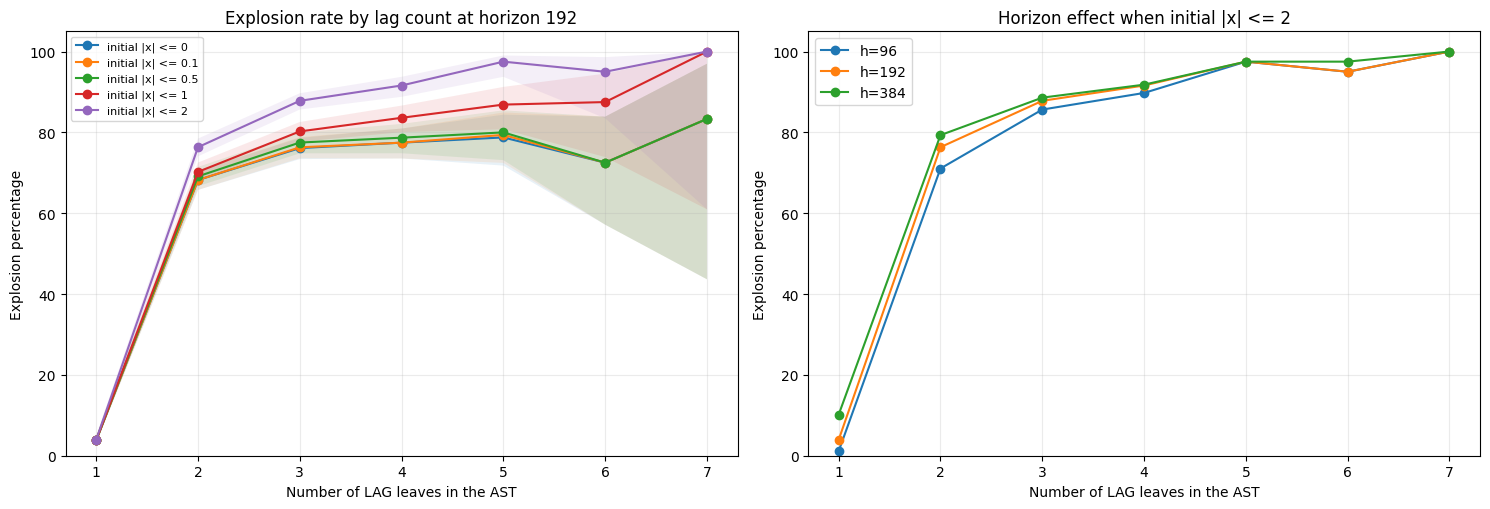

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

for input_abs_limit, group in reference_summary.groupby("input_abs_limit"):
    group = group.sort_values("lag_count")
    axes[0].plot(
        group["lag_count"],
        100.0 * group["explosion_rate"],
        marker="o",
        label=f"initial |x| <= {input_abs_limit:g}",
    )
    axes[0].fill_between(
        group["lag_count"],
        100.0 * group["wilson_95_low"],
        100.0 * group["wilson_95_high"],
        alpha=0.10,
    )
axes[0].set(
    title="Explosion rate by lag count at horizon 192",
    xlabel="Number of LAG leaves in the AST",
    ylabel="Explosion percentage",
    ylim=(0, 105),
)
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8)

largest_bound = max(INPUT_ABS_LIMITS)
largest_bound_summary = lag_explosion_summary[
    lag_explosion_summary["input_abs_limit"].eq(largest_bound)
]
for horizon, group in largest_bound_summary.groupby("horizon"):
    group = group.sort_values("lag_count")
    axes[1].plot(
        group["lag_count"],
        100.0 * group["explosion_rate"],
        marker="o",
        label=f"h={horizon}",
    )
axes[1].set(
    title=f"Horizon effect when initial |x| <= {largest_bound:g}",
    xlabel="Number of LAG leaves in the AST",
    ylabel="Explosion percentage",
    ylim=(0, 105),
)
axes[1].grid(alpha=0.25)
axes[1].legend()

fig.tight_layout()
plt.show()

**O que foi feito.** O primeiro gráfico compara as condições iniciais no horizonte de referência. O segundo mostra como a relação muda com o horizonte na condição inicial mais ampla.

## 5. Interpretação sem confundir associação com causalidade

A comparação abaixo destaca a passagem de uma para duas folhas de lag e calcula a associação monotônica em cada condição. Ela não substitui o experimento de intervenção que manterá a estrutura e adicionará coeficientes aos lags.

In [6]:
reference_outcomes = outcomes[outcomes["horizon"].eq(REFERENCE_HORIZON)]
association_rows = []
for input_abs_limit, group in reference_outcomes.groupby("input_abs_limit"):
    rates = group.groupby("lag_count")["exploded"].mean()
    association_rows.append({
        "input_abs_limit": input_abs_limit,
        "one_lag_percent": 100.0 * rates.loc[1],
        "two_lags_percent": 100.0 * rates.loc[2],
        "percentage_point_increase_1_to_2": 100.0 * (rates.loc[2] - rates.loc[1]),
        "spearman_lag_explosion": group[["lag_count", "exploded"]].corr(method="spearman").iloc[0, 1],
    })

association = pd.DataFrame(association_rows)
display(association.round(3))

zero_bound = association[association["input_abs_limit"].eq(0.0)].iloc[0]
print(
    f"At initial bound zero, explosion increases from {zero_bound['one_lag_percent']:.2f}% "
    f"with one lag to {zero_bound['two_lags_percent']:.2f}% with two lags "
    f"(+{zero_bound['percentage_point_increase_1_to_2']:.2f} percentage points)."
)

,input_abs_limit,one_lag_percent,two_lags_percent,percentage_point_increase_1_to_2,spearman_lag_explosion
0,0.0,3.842,68.217,64.375,0.614
1,0.1,3.842,68.217,64.375,0.615
2,0.5,3.842,69.119,65.277,0.624
3,1.0,3.842,70.229,66.387,0.661
4,2.0,3.950,76.336,72.386,0.731


At initial bound zero, explosion increases from 3.84% with one lag to 68.22% with two lags (+64.37 percentage points).


**O que foi feito.** O salto entre uma e duas folhas de lag é quantificado, junto com uma medida descritiva de associação monotônica. O resultado sustenta a hipótese de risco, mas árvore maior, mais adições e mais lags variam conjuntamente; o teste causal será comparar árvores pareadas antes e depois do coefficient gating.

## 6. Registro completo do experimento

Esta célula contém a pergunta, hipótese, configuração, proveniência, sementes, métricas, interpretação, limitações e comando exato de reprodução.

In [7]:
def git_output(*arguments: str) -> str | None:
    try:
        return subprocess.check_output(
            ["git", *arguments],
            cwd=PROJECT_ROOT,
            text=True,
            stderr=subprocess.DEVNULL,
        ).strip()
    except (subprocess.CalledProcessError, FileNotFoundError):
        return None


def json_records(frame: pd.DataFrame) -> list[dict]:
    return json.loads(frame.to_json(orient="records"))


package_versions = {
    name: importlib.metadata.version(name)
    for name in ["numpy", "pandas", "matplotlib"]
}

one_lag_zero = reference_summary[
    reference_summary["input_abs_limit"].eq(0.0)
    & reference_summary["lag_count"].eq(1)
].iloc[0]
two_lag_zero = reference_summary[
    reference_summary["input_abs_limit"].eq(0.0)
    & reference_summary["lag_count"].eq(2)
].iloc[0]

experiment_record = {
    "experiment_id": "abstract_syntax_tree_stability_mitigation_000_lag_count_explosion_evidence",
    "status": "executed",
    "research_question": (
        "How does empirical explosion frequency vary with the number of Lag nodes in the baseline recurrent AST?"
    ),
    "hypothesis": (
        "Trees containing more lag leaves have a higher explosion rate because bare lags can contribute implicit unit gain, "
        "especially when combined additively."
    ),
    "configuration": configuration,
    "seed_policy": {
        "mechanism_seed": "derive_sample_seed(ROOT_SEED, sample_index)",
        "paired_trajectory_seed": "SeedSequence([ROOT_SEED, sample_index, 991])",
        "same_trajectory_prefixes_across_horizons": True,
        "same_innovations_across_initial_bounds": True,
        "external_global_rng_used": False,
    },
    "provenance": {
        "baseline_notebook": "experiments/abstract_syntax_tree/4_large_scale_stability_and_equivalence.ipynb",
        "implementation": [
            "src/tsfmxai/generators/random_expression.py",
            "src/tsfmxai/generators/trajectory.py",
            "src/tsfmxai/representations/expression.py",
        ],
        "project_head": git_output("rev-parse", "HEAD"),
        "python": sys.version,
        "platform": platform.platform(),
        "packages": package_versions,
    },
    "metrics": {
        "sampling_seconds": sampling_seconds,
        "simulation_seconds": simulation_seconds,
        "lag_support": json_records(lag_support.reset_index()),
        "explosion_by_horizon_initial_bound_and_lag_count": json_records(lag_explosion_summary),
        "reference_horizon_association": json_records(association),
        "reproduced_notebook_4_horizon_192_totals": observed_reference_explosions,
    },
    "scientific_summary": (
        f"At horizon {REFERENCE_HORIZON} with zero initial bound, explosion frequency increased from "
        f"{one_lag_zero['explosion_rate']:.2%} for one lag ({int(one_lag_zero['evaluated_mechanisms'])} mechanisms) to "
        f"{two_lag_zero['explosion_rate']:.2%} for two lags ({int(two_lag_zero['evaluated_mechanisms'])} mechanisms). "
        "Higher lag-count groups generally retained high explosion rates, but the smallest groups have wide uncertainty. "
        "The result is associational because lag count covaries with tree size and operator composition."
    ),
    "limitations": [
        "Lag count is the number of Lag nodes, not the number of distinct numeric lag values.",
        "The analysis does not isolate lag count from tree size, addition count, multiplication count, or coefficient placement.",
        "Groups with six or seven Lag nodes contain few mechanisms and have wide Wilson intervals.",
        "Causal support for coefficient-gated lags requires a paired intervention experiment.",
    ],
    "reproduction_command": (
        r".\.venv\Scripts\python.exe -m jupyter nbconvert --to notebook --execute "
        r"experiments\abstract_syntax_tree\stability_mitigation\00_lag_count_explosion_evidence.ipynb "
        r"--inplace --ExecutePreprocessor.timeout=2400"
    ),
}

print(json.dumps(experiment_record, indent=2, ensure_ascii=False))

{
  "experiment_id": "abstract_syntax_tree_stability_mitigation_000_lag_count_explosion_evidence",
  "status": "executed",
  "research_question": "How does empirical explosion frequency vary with the number of Lag nodes in the baseline recurrent AST?",
  "hypothesis": "Trees containing more lag leaves have a higher explosion rate because bare lags can contribute implicit unit gain, especially when combined additively.",
  "configuration": {
    "root_seed": 20261001,
    "sample_count": 5000,
    "horizons": [
      96,
      192,
      384
    ],
    "reference_horizon": 192,
    "innovation_std": 0.05,
    "input_absolute_limits": [
      0.0,
      0.1,
      0.5,
      1.0,
      2.0
    ],
    "explosion_limit": 100.0,
    "lag_count_definition": "number of Lag nodes in the canonical AST",
    "tree_config": {
      "minimum_operators": 1,
      "maximum_operators": 6,
      "num_series": 1,
      "minimum_lag": 1,
      "maximum_lag": 12,
      "parameter_probability": 0.55,
    

**Interpretação do registro.** O experimento reproduz o total de explosões do Notebook 4 e acrescenta a estratificação por número de folhas de lag. Ele fornece evidência descritiva para priorizar coefficient gating, sem apresentar a associação observada como uma garantia causal.